# Brent–WTI Backtest: Period Returns, P&L, Spread, and Trade Log

This notebook runs the repository's executable Brent–WTI mean-reversion
strategy across every locally available, execution-ready one-minute data
period. The current sample covers **twelve independent weeks spanning 2023
through 2026**, including three consecutive May blocks in both 2024 and
2025. Every sample uses the same **30-minute strategy window**, so
the comparison tests different calendar periods rather than different model
settings. The notebook reports:

- return and P&L by market-data period;
- synthetic spread behavior and quoted listed-spread width;
- completed trades, win rate, and average holding time;
- cumulative P&L reset within each period; and
- a complete round-trip trade log.

Execution is conservative: long positions pay the listed spread ask and sell
the bid; short positions sell the bid and cover at the ask. Therefore the P&L
includes the observed bid–ask cost. All timestamps are UTC.

In [1]:
from pathlib import Path
import os
import sys
import tempfile
import warnings

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mplconfig-backtest-"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "_data" / "clean"
OUTPUT_DIR = PROJECT_ROOT / "_output" / "backtesting_period_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from strategy_engine import run_strategy

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

Matplotlib is building the font cache; this may take a moment.


## Configuration

The rolling mean, standard deviation, stationarity tests, and half-life
estimate all use 30 one-minute observations. All parameters are fixed across
calendar periods.

In [2]:
CONTRACT_MULTIPLIER = 1_000.0

BACKTEST_CONFIGS = {
    "30-minute": {
        "window": 30,
        "deviation_threshold": 2.5,
        "halflife_threshold": 15.0,
        "exit_threshold": 0.5,
        "stop_loss": 1_000.0,
        "time_stop": 30,
    },
}

BASELINE_CONFIG = "30-minute"

config_table = pd.DataFrame(BACKTEST_CONFIGS).T
config_table.index.name = "configuration"
config_table

,window,deviation_threshold,halflife_threshold,exit_threshold,stop_loss,time_stop
configuration,,,,,,
30-minute,30.0,2.5,15.0,0.5,1000.0,30.0


## Load the independent market-data periods

Each parquet file is treated as a separate backtest period. Exactly three
consecutive blocks are selected for each year; later downloaded extensions
are deliberately excluded. Rolling windows, open positions, and cumulative
P&L never carry across a file boundary.

In [3]:
required_columns = {
    "synth_mid",
    "ls_mid",
    "ls_bid_px_00",
    "ls_ask_px_00",
    "cl_mid",
    "bz_mid",
    "cl_instrument_id",
    "bz_instrument_id",
    "cl_n_events",
    "bz_n_events",
}

SELECTED_PERIOD_FILES = [
    "stable_2023_brent_wti_aligned_1m_2023-05-01_2023-05-06.parquet",
    "stable_2023_brent_wti_aligned_1m_2023-05-06_2023-05-13.parquet",
    "stable_2023_brent_wti_aligned_1m_2023-05-13_2023-05-20.parquet",
    "brent_wti_aligned_1m_2024-05-01_2024-05-06.parquet",
    "brent_wti_aligned_1m_2024-05-06_2024-05-13.parquet",
    "brent_wti_aligned_1m_2024-05-13_2024-05-20.parquet",
    "brent_wti_aligned_1m_2025-05-01_2025-05-06.parquet",
    "brent_wti_aligned_1m_2025-05-06_2025-05-13.parquet",
    "brent_wti_aligned_1m_2025-05-13_2025-05-20.parquet",
    "brent_wti_aligned_1m_2026-06-01_2026-06-06.parquet",
    "brent_wti_aligned_1m_2026-06-06_2026-06-13.parquet",
    "brent_wti_aligned_1m_2026-06-13_2026-06-20.parquet",
]

missing_files = [name for name in SELECTED_PERIOD_FILES if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing selected three-week data files: {missing_files}")

loaded_periods = []
for filename in SELECTED_PERIOD_FILES:
    path = DATA_DIR / filename
    frame = pd.read_parquet(path).sort_index()
    missing_columns = required_columns.difference(frame.columns)
    if missing_columns:
        raise ValueError(f"{path.name} is missing required columns: {sorted(missing_columns)}")
    loaded_periods.append((path, frame))

loaded_periods.sort(key=lambda item: item[1].index.min())
period_paths = [path for path, _ in loaded_periods]
if not period_paths:
    raise FileNotFoundError(
        f"No execution-ready aligned one-minute parquet files found in {DATA_DIR}. "
        "Run the data-cleaning pipeline first."
    )
assert len(period_paths) == 12


def period_name(path: Path) -> str:
    stem = path.stem
    if stem.startswith("stable_2023_brent_wti_aligned_1m_"):
        return "2023 stable | " + stem.removeprefix("stable_2023_brent_wti_aligned_1m_")
    dates = stem.removeprefix("brent_wti_aligned_1m_")
    return f"{dates[:4]} | {dates}"


period_data = {period_name(path): frame for path, frame in loaded_periods}

data_inventory = pd.DataFrame(
    [
        {
            "period": name,
            "rows": len(frame),
            "start_utc": frame.index.min(),
            "end_utc": frame.index.max(),
            "non_null_spread": frame["synth_mid"].notna().sum(),
        }
        for name, frame in period_data.items()
    ]
).set_index("period")
data_inventory

,rows,start_utc,end_utc,non_null_spread
period,,,,
2023 stable | 2023-05-01_2023-05-06,7021,2023-05-01 00:00:00+00:00,2023-05-05 21:00:00+00:00,6835
2023 stable | 2023-05-06_2023-05-13,7321,2023-05-07 19:00:00+00:00,2023-05-12 21:00:00+00:00,7001
2023 stable | 2023-05-13_2023-05-20,7321,2023-05-14 19:00:00+00:00,2023-05-19 21:00:00+00:00,6960
2024 | 2024-05-01_2024-05-06,7200,2024-05-01 00:00:00+00:00,2024-05-05 23:59:00+00:00,4245
2024 | 2024-05-06_2024-05-13,10080,2024-05-06 00:00:00+00:00,2024-05-12 23:59:00+00:00,7031
2024 | 2024-05-13_2024-05-20,10080,2024-05-13 00:00:00+00:00,2024-05-19 23:59:00+00:00,7027
2025 | 2025-05-01_2025-05-06,7200,2025-05-01 00:00:00+00:00,2025-05-05 23:59:00+00:00,4199
2025 | 2025-05-06_2025-05-13,10080,2025-05-06 00:00:00+00:00,2025-05-12 23:59:00+00:00,6998
2025 | 2025-05-13_2025-05-20,10080,2025-05-13 00:00:00+00:00,2025-05-19 23:59:00+00:00,6993


## Run the 30-minute strategy against every data period

The engine enforces its normal 00:00–19:59 UTC trading window and closes an
open position before a timestamp gap or at the end of each input sample.

In [4]:
results = {}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for config_name, parameters in BACKTEST_CONFIGS.items():
        for period, frame in period_data.items():
            key = (config_name, period)
            results[key] = run_strategy(
                data=frame,
                contract_multiplier=CONTRACT_MULTIPLIER,
                **parameters,
            )

run_inventory = pd.DataFrame(
    [
        {
            "configuration": config_name,
            "period": period,
            "bars": len(run),
            "entries": int(run["long_entry"].fillna(False).sum() + run["short_entry"].fillna(False).sum()),
            "exits": int(run["exit_flag"].fillna(False).sum()),
        }
        for (config_name, period), run in results.items()
    ]
)

assert (run_inventory["entries"] == run_inventory["exits"]).all(), "Every entry should have a matching exit."
run_inventory

,configuration,period,bars,entries,exits
0,30-minute,2023 stable | 2023-05-01_2023-05-06,6000,13,13
1,30-minute,2023 stable | 2023-05-06_2023-05-13,6060,12,12
2,30-minute,2023 stable | 2023-05-13_2023-05-20,6060,8,8
3,30-minute,2024 | 2024-05-01_2024-05-06,6000,6,6
4,30-minute,2024 | 2024-05-06_2024-05-13,8400,23,23
5,30-minute,2024 | 2024-05-13_2024-05-20,8400,8,8
6,30-minute,2025 | 2025-05-01_2025-05-06,6000,9,9
7,30-minute,2025 | 2025-05-06_2025-05-13,8400,17,17
8,30-minute,2025 | 2025-05-13_2025-05-20,8400,15,15
9,30-minute,2026 | 2026-06-01_2026-06-06,6000,4,4


## Build the round-trip trade log

`trade_return` is executable trade P&L divided by the absolute spread-entry
notional (`abs(entry_price) × 1,000`). This is useful for comparing trades,
but it is not a return on margin or portfolio capital. The latter requires a
separately specified capital base.

In [5]:
def build_trade_log(run: pd.DataFrame, configuration: str, period: str) -> pd.DataFrame:
    """Pair each entry with its exit and return one row per completed trade."""
    trades = []
    active = None

    for timestamp, row in run.iterrows():
        is_long_entry = bool(pd.notna(row["long_entry"]) and row["long_entry"])
        is_short_entry = bool(pd.notna(row["short_entry"]) and row["short_entry"])

        if is_long_entry or is_short_entry:
            active = {
                "configuration": configuration,
                "period": period,
                "entry_time": timestamp,
                "side": "long" if is_long_entry else "short",
                "position": 1 if is_long_entry else -1,
                "entry_price": float(row["entry_price"]),
                "entry_synth_spread": float(row["synth_mid"]),
                "entry_zscore": float(row["zscore"]),
                "entry_halflife": float(row["halflife"]),
                "entry_quoted_width": float(row["ls_ask"] - row["ls_bid"]),
            }

        if bool(pd.notna(row["exit_flag"]) and row["exit_flag"]):
            if active is None:
                raise RuntimeError(f"Exit without an entry at {timestamp}")

            if active["position"] == 1:
                exit_price = float(row["ls_bid"])
            else:
                exit_price = float(row["ls_ask"])

            pnl = float(row["position_pnl"])
            entry_notional = abs(active["entry_price"]) * CONTRACT_MULTIPLIER
            active.update(
                {
                    "exit_time": timestamp,
                    "exit_price": exit_price,
                    "exit_synth_spread": float(row["synth_mid"]),
                    "exit_zscore": float(row["zscore"]) if pd.notna(row["zscore"]) else np.nan,
                    "zscore_change": (
                        float(row["zscore"] - active["entry_zscore"])
                        if pd.notna(row["zscore"])
                        else np.nan
                    ),
                    "holding_minutes": int(row["position_age"]),
                    "pnl_usd": pnl,
                    "trade_return": pnl / entry_notional if entry_notional > 0 else np.nan,
                    "exit_reason": row["exit_reason"],
                }
            )
            trades.append(active)
            active = None

    if active is not None:
        raise RuntimeError(f"Unclosed trade remains in {configuration}, {period}")

    return pd.DataFrame(trades)


trade_frames = [
    build_trade_log(run, configuration, period)
    for (configuration, period), run in results.items()
]
trade_log = pd.concat(trade_frames, ignore_index=True) if trade_frames else pd.DataFrame()
trade_log.insert(0, "trade_id", np.arange(1, len(trade_log) + 1))

## P&L, return, spread, and trades by period

- `pnl_usd` is the sum of executable minute-by-minute P&L.
- `period_return` divides P&L by the sum of absolute entry notionals. It is a
  trade-normalized comparison, not a return on portfolio capital.
- `mean_synth_spread` and `synth_spread_volatility` describe the CL–BZ signal.
- `mean_quoted_width` is the average bid–ask width of the exchange-listed
  spread used for fills.

In [6]:
def summarize_period(configuration: str, period: str, run: pd.DataFrame) -> dict:
    trades = trade_log.loc[
        trade_log["configuration"].eq(configuration) & trade_log["period"].eq(period)
    ]
    pnl = float(run["step_pnl"].fillna(0).sum())
    entry_notional = (trades["entry_price"].abs() * CONTRACT_MULTIPLIER).sum()
    listed_width = run["ls_ask"] - run["ls_bid"]

    return {
        "configuration": configuration,
        "year": int(run.index.min().year),
        "period": period,
        "start_utc": run.index.min(),
        "end_utc": run.index.max(),
        "pnl_usd": pnl,
        "period_return": pnl / entry_notional if entry_notional > 0 else np.nan,
        "mean_synth_spread": run["synth_mid"].mean(),
        "synth_spread_volatility": run["synth_mid"].std(),
        "mean_quoted_width": listed_width.mean(),
        "trades": len(trades),
        "winning_trades": int(trades["pnl_usd"].gt(0).sum()),
        "win_rate": trades["pnl_usd"].gt(0).mean() if len(trades) else np.nan,
        "average_trade_pnl": trades["pnl_usd"].mean() if len(trades) else np.nan,
        "average_holding_minutes": trades["holding_minutes"].mean() if len(trades) else np.nan,
    }


period_summary = pd.DataFrame(
    [summarize_period(configuration, period, run) for (configuration, period), run in results.items()]
).sort_values(["configuration", "period"])

# Bar-level and round-trip P&L must reconcile for every independent run.
trade_pnl_check = (
    trade_log.groupby(["configuration", "period"])["pnl_usd"]
    .sum()
    .reindex(pd.MultiIndex.from_frame(period_summary[["configuration", "period"]]), fill_value=0.0)
    .to_numpy()
)
assert np.allclose(period_summary["pnl_usd"], trade_pnl_check), "Trade-log P&L does not reconcile."

period_summary.style.format(
    {
        "pnl_usd": "${:,.2f}",
        "period_return": "{:.2%}",
        "mean_synth_spread": "{:.4f}",
        "synth_spread_volatility": "{:.4f}",
        "mean_quoted_width": "{:.4f}",
        "win_rate": "{:.1%}",
        "average_trade_pnl": "${:,.2f}",
        "average_holding_minutes": "{:.1f}",
    }
).hide(axis="index").set_caption("Performance by independent 30-minute backtest period")

configuration,year,period,start_utc,end_utc,pnl_usd,period_return,mean_synth_spread,synth_spread_volatility,mean_quoted_width,trades,winning_trades,win_rate,average_trade_pnl,average_holding_minutes
30-minute,2023,2023 stable | 2023-05-01_2023-05-06,2023-05-01 00:00:00+00:00,2023-05-05 19:59:00+00:00,$-210.00,-0.43%,-3.7728,0.1469,0.0163,13,1,7.7%,$-16.15,9.0
30-minute,2023,2023 stable | 2023-05-06_2023-05-13,2023-05-07 19:00:00+00:00,2023-05-12 19:59:00+00:00,$-210.00,-0.45%,-3.8741,0.1183,0.0155,12,2,16.7%,$-17.50,11.2
30-minute,2023,2023 stable | 2023-05-13_2023-05-20,2023-05-14 19:00:00+00:00,2023-05-19 19:59:00+00:00,$-130.00,-0.40%,-4.0912,0.0423,0.0213,8,1,12.5%,$-16.25,11.6
30-minute,2024,2024 | 2024-05-01_2024-05-06,2024-05-01 00:00:00+00:00,2024-05-05 19:59:00+00:00,$-80.00,-0.29%,-4.5803,0.1474,0.0155,6,1,16.7%,$-13.33,9.0
30-minute,2024,2024 | 2024-05-06_2024-05-13,2024-05-06 00:00:00+00:00,2024-05-12 19:59:00+00:00,$-450.00,-0.42%,-4.6834,0.1274,0.0164,23,0,0.0%,$-19.57,12.3
30-minute,2024,2024 | 2024-05-13_2024-05-20,2024-05-13 00:00:00+00:00,2024-05-19 19:59:00+00:00,$-100.00,-0.29%,-4.2316,0.1531,0.0159,8,0,0.0%,$-12.50,5.1
30-minute,2025,2025 | 2025-05-01_2025-05-06,2025-05-01 00:00:00+00:00,2025-05-05 19:59:00+00:00,$-110.00,-0.42%,-2.9618,0.0932,0.0120,9,0,0.0%,$-12.22,7.9
30-minute,2025,2025 | 2025-05-06_2025-05-13,2025-05-06 00:00:00+00:00,2025-05-12 19:59:00+00:00,$-180.00,-0.35%,-2.9661,0.0849,0.0115,17,1,5.9%,$-10.59,7.9
30-minute,2025,2025 | 2025-05-13_2025-05-20,2025-05-13 00:00:00+00:00,2025-05-19 19:59:00+00:00,$-170.00,-0.39%,-3.0277,0.1939,0.0115,15,1,6.7%,$-11.33,10.1
30-minute,2026,2026 | 2026-06-01_2026-06-06,2026-06-01 00:00:00+00:00,2026-06-05 19:59:00+00:00,$330.00,3.70%,-2.4875,0.5603,0.0247,4,2,50.0%,$82.50,16.2


## Overall 30-minute strategy result

In [7]:
overall_summary = (
    period_summary.groupby("configuration", sort=False)
    .agg(
        pnl_usd=("pnl_usd", "sum"),
        trades=("trades", "sum"),
        winning_trades=("winning_trades", "sum"),
        average_period_return=("period_return", "mean"),
        average_quoted_width=("mean_quoted_width", "mean"),
    )
)

trade_averages = trade_log.groupby("configuration").agg(
    average_trade_pnl=("pnl_usd", "mean"),
    average_holding_minutes=("holding_minutes", "mean"),
)
overall_summary = overall_summary.join(trade_averages)
overall_summary["win_rate"] = overall_summary["winning_trades"] / overall_summary["trades"]

overall_summary.style.format(
    {
        "pnl_usd": "${:,.2f}",
        "average_period_return": "{:.2%}",
        "average_quoted_width": "{:.4f}",
        "average_trade_pnl": "${:,.2f}",
        "average_holding_minutes": "{:.1f}",
        "win_rate": "{:.1%}",
    }
).set_caption("Overall 30-minute strategy performance")

,pnl_usd,trades,winning_trades,average_period_return,average_quoted_width,average_trade_pnl,average_holding_minutes,win_rate
configuration,,,,,,,,
30-minute,"$-1,470.00",125,13,-0.04%,0.0179,$-11.76,10.0,10.4%


## Combined performance by year

Annual P&L and trade counts sum the independent weekly backtests in that
year. `year_return` divides annual P&L by total absolute entry notional; it is
a trade-normalized comparison, not a return on portfolio capital.

In [8]:
trade_log.insert(1, "year", pd.to_datetime(trade_log["entry_time"], utc=True).dt.year)
year_trade_summary = trade_log.groupby("year").agg(
    entry_notional=("entry_price", lambda values: values.abs().sum() * CONTRACT_MULTIPLIER),
    average_trade_pnl=("pnl_usd", "mean"),
    average_holding_minutes=("holding_minutes", "mean"),
)

year_summary = (
    period_summary.groupby("year")
    .agg(
        weeks=("period", "count"),
        pnl_usd=("pnl_usd", "sum"),
        trades=("trades", "sum"),
        winning_trades=("winning_trades", "sum"),
        average_quoted_width=("mean_quoted_width", "mean"),
    )
    .join(year_trade_summary)
)
year_summary["win_rate"] = year_summary["winning_trades"] / year_summary["trades"]
year_summary["year_return"] = year_summary["pnl_usd"] / year_summary["entry_notional"]

year_summary.style.format(
    {
        "pnl_usd": "${:,.2f}",
        "average_quoted_width": "{:.4f}",
        "entry_notional": "${:,.2f}",
        "average_trade_pnl": "${:,.2f}",
        "average_holding_minutes": "{:.1f}",
        "win_rate": "{:.1%}",
        "year_return": "{:.2%}",
    }
).set_caption("Performance by year")

,weeks,pnl_usd,trades,winning_trades,average_quoted_width,entry_notional,average_trade_pnl,average_holding_minutes,win_rate,year_return
year,,,,,,,,,,
2023,3,$-550.00,33,4,0.0177,"$128,540.00",$-16.67,10.5,12.1%,-0.43%
2024,3,$-630.00,37,1,0.0160,"$169,980.00",$-17.03,10.2,2.7%,-0.37%
2025,3,$-460.00,41,2,0.0116,"$120,410.00",$-11.22,8.7,4.9%,-0.38%
2026,3,$170.00,14,6,0.0263,"$39,150.00",$12.14,12.2,42.9%,0.43%


## Connected spread and cumulative P&L by year

The three blocks for each year are joined chronologically into a connected
spread line and a connected cumulative-P&L line. Strategy state still resets
at each block boundary; dotted vertical lines mark those boundaries. Entry
markers are green for longs, red for shorts, and purple crosses for exits.

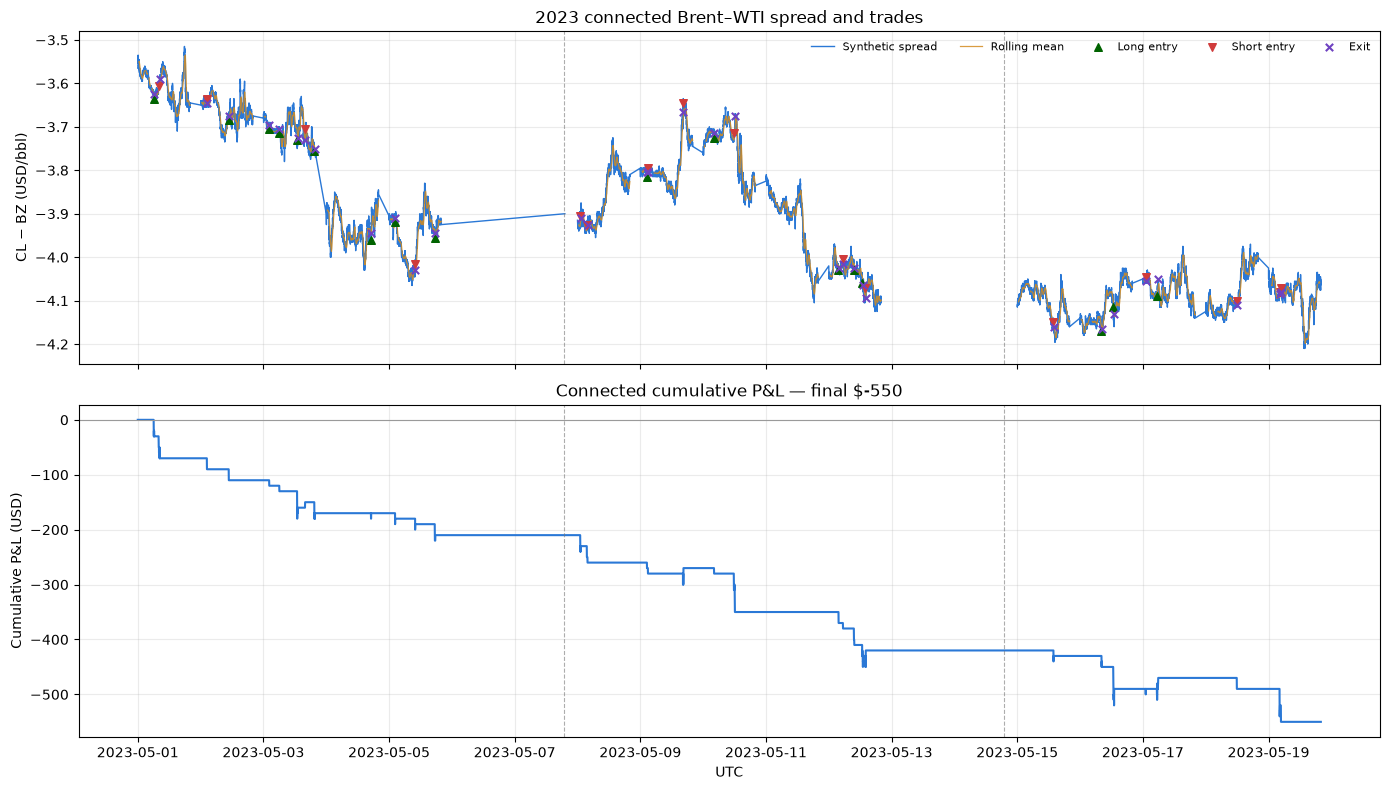

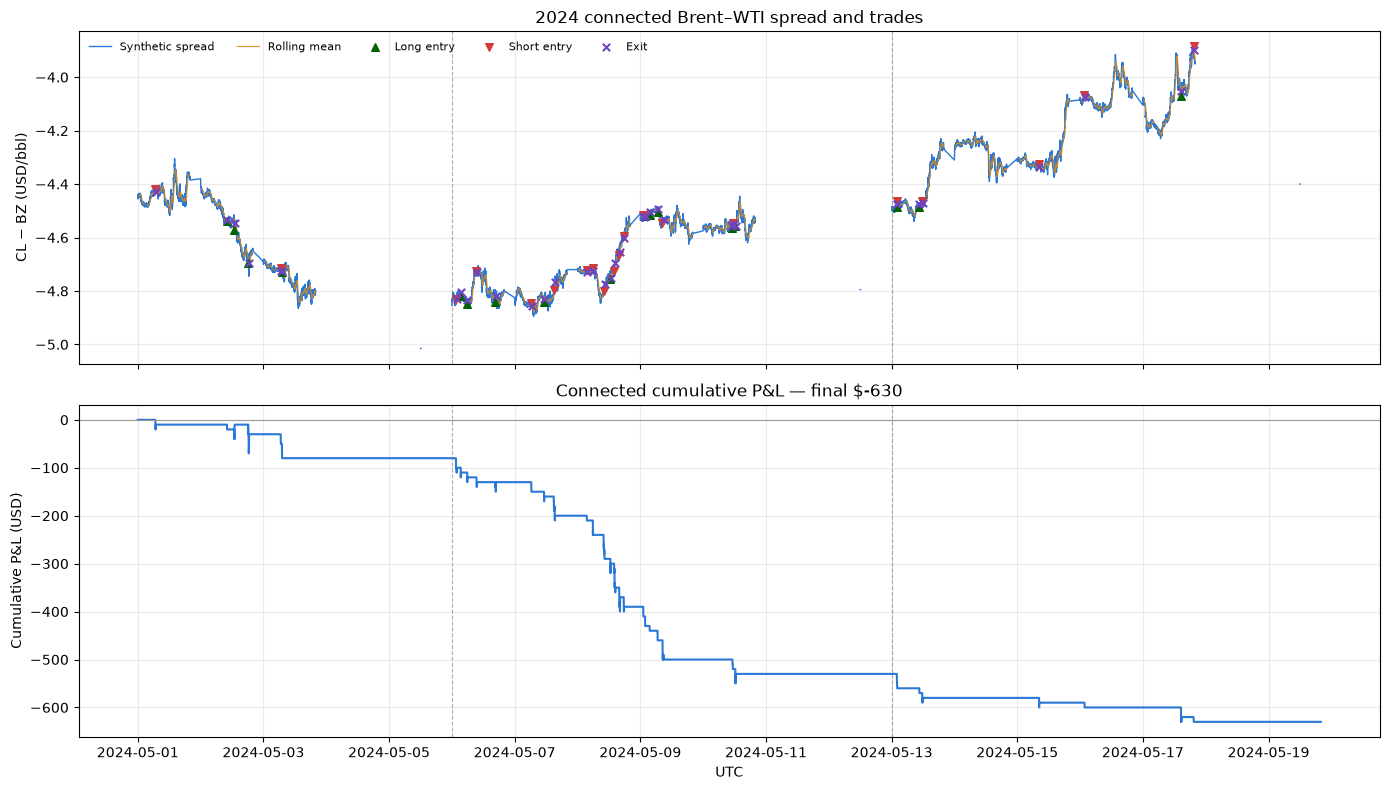

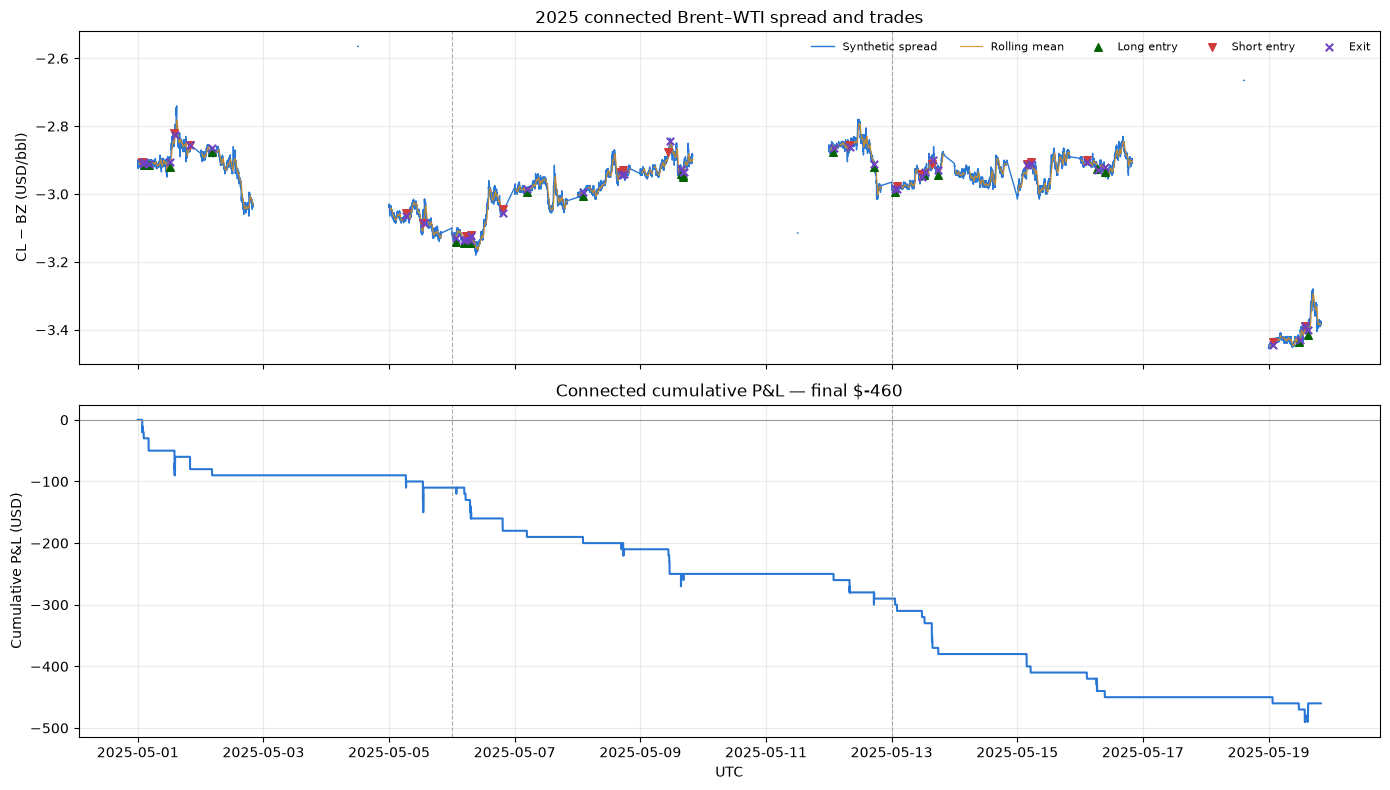

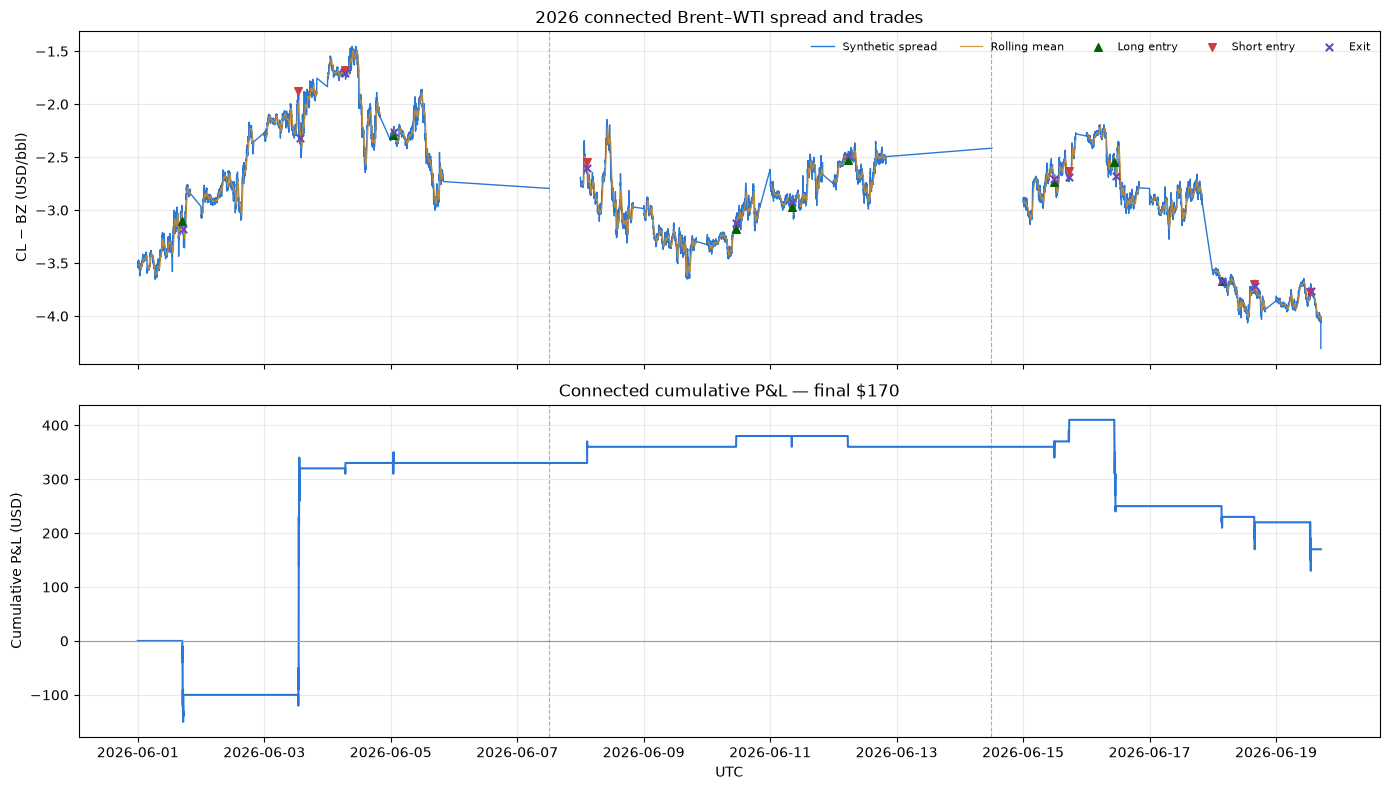

In [9]:
baseline_periods = [(period, results[(BASELINE_CONFIG, period)]) for period in period_data]
YEAR_FIGURE_DIR = PROJECT_ROOT / "docs_src" / "figures"
YEAR_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for year in sorted(period_summary["year"].unique()):
    year_periods = [
        (period, run)
        for period, run in baseline_periods
        if run.index.min().year == year
    ]
    offset = 0.0
    pnl_pieces = []
    spread_pieces = []
    mean_pieces = []
    boundaries = []

    for _, run in year_periods:
        cumulative = run["step_pnl"].fillna(0).cumsum() + offset
        pnl_pieces.append(cumulative)
        spread_pieces.append(run["synth_mid"])
        mean_pieces.append(run["rolling_mean"])
        boundaries.append(run.index.min())
        if len(cumulative):
            offset = float(cumulative.iloc[-1])

    annual_pnl = pd.concat(pnl_pieces)
    annual_spread = pd.concat(spread_pieces)
    annual_mean = pd.concat(mean_pieces)
    annual_runs = pd.concat([run for _, run in year_periods])
    longs = annual_runs[annual_runs["long_entry"].fillna(False)]
    shorts = annual_runs[annual_runs["short_entry"].fillna(False)]
    exits = annual_runs[annual_runs["exit_flag"].fillna(False)]

    fig, (spread_ax, pnl_ax) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    spread_ax.plot(annual_spread.index, annual_spread, color="#2a78d6", lw=1.0, label="Synthetic spread")
    spread_ax.plot(annual_mean.index, annual_mean, color="#d38b1f", lw=0.9, alpha=0.85, label="Rolling mean")
    spread_ax.scatter(longs.index, longs["synth_mid"], marker="^", color="#006300", s=30, label="Long entry", zorder=3)
    spread_ax.scatter(shorts.index, shorts["synth_mid"], marker="v", color="#d03b3b", s=30, label="Short entry", zorder=3)
    spread_ax.scatter(exits.index, exits["synth_mid"], marker="x", color="#6f42c1", s=28, label="Exit", zorder=3)
    spread_ax.set_title(f"{year} connected Brent–WTI spread and trades")
    spread_ax.set_ylabel("CL − BZ (USD/bbl)")
    spread_ax.legend(frameon=False, ncols=5, fontsize=8)
    spread_ax.grid(alpha=0.25)

    pnl_ax.plot(annual_pnl.index, annual_pnl, color="#2a78d6", lw=1.5)
    pnl_ax.axhline(0, color="#9a9a9a", lw=0.8)
    pnl_ax.set_title(f"Connected cumulative P&L — final ${offset:,.0f}")
    pnl_ax.set_ylabel("Cumulative P&L (USD)")
    pnl_ax.set_xlabel("UTC")
    pnl_ax.grid(alpha=0.25)

    for boundary in boundaries[1:]:
        spread_ax.axvline(boundary, color="#777777", ls="--", lw=0.8, alpha=0.6)
        pnl_ax.axvline(boundary, color="#777777", ls="--", lw=0.8, alpha=0.6)

    fig.tight_layout()
    fig.savefig(
        YEAR_FIGURE_DIR / f"strategy_yearly_spread_pnl_{year}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

## Full trade log

The table below is intentionally unaggregated so every entry and exit can be
audited. The CSV and parquet exports preserve all rows even when the notebook
display is truncated.

In [10]:
trade_log.style.format(
    {
        "entry_price": "{:.4f}",
        "exit_price": "{:.4f}",
        "entry_synth_spread": "{:.4f}",
        "exit_synth_spread": "{:.4f}",
        "entry_zscore": "{:.3f}",
        "exit_zscore": "{:.3f}",
        "zscore_change": "{:.3f}",
        "entry_halflife": "{:.2f}",
        "entry_quoted_width": "{:.4f}",
        "holding_minutes": "{:,.0f}",
        "pnl_usd": "${:,.2f}",
        "trade_return": "{:.2%}",
    }
).set_caption("Complete 2023–2026 trade log")

,trade_id,year,configuration,period,entry_time,side,position,entry_price,entry_synth_spread,entry_zscore,entry_halflife,entry_quoted_width,exit_time,exit_price,exit_synth_spread,exit_zscore,zscore_change,holding_minutes,pnl_usd,trade_return,exit_reason
0,1,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-01 06:04:00+00:00,long,1,-3.6200,-3.6350,-2.835,0.62,0.0200,2023-05-01 06:16:00+00:00,-3.6500,-3.6250,0.318,3.154,12,$-30.00,-0.83%,mean_reversion
1,2,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-01 07:57:00+00:00,short,-1,-3.6200,-3.6050,2.789,0.31,0.0200,2023-05-01 08:27:00+00:00,-3.5800,-3.5900,1.466,-1.323,30,$-40.00,-1.10%,time_stop
2,3,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-02 02:23:00+00:00,short,-1,-3.6500,-3.6350,2.944,0.32,0.0200,2023-05-02 02:37:00+00:00,-3.6300,-3.6450,-0.195,-3.140,14,$-20.00,-0.55%,mean_reversion
3,4,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-02 10:44:00+00:00,long,1,-3.6700,-3.6850,-3.022,0.02,0.0200,2023-05-02 10:45:00+00:00,-3.6900,-3.6750,0.104,3.127,1,$-20.00,-0.54%,mean_reversion
4,5,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-03 02:11:00+00:00,long,1,-3.6900,-3.7050,-3.393,0.24,0.0100,2023-05-03 02:13:00+00:00,-3.7000,-3.6950,-0.165,3.228,2,$-10.00,-0.27%,mean_reversion
5,6,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-03 06:03:00+00:00,long,1,-3.7000,-3.7150,-2.830,0.55,0.0100,2023-05-03 06:07:00+00:00,-3.7100,-3.7050,0.046,2.877,4,$-10.00,-0.27%,mean_reversion
6,7,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-03 12:51:00+00:00,long,1,-3.7100,-3.7300,-3.635,0.41,0.0200,2023-05-03 13:03:00+00:00,-3.7400,-3.7250,-0.340,3.295,12,$-30.00,-0.81%,mean_reversion
7,8,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-03 15:53:00+00:00,short,-1,-3.7100,-3.7050,3.116,0.22,0.0100,2023-05-03 15:55:00+00:00,-3.7200,-3.7300,-0.089,-3.205,2,$10.00,0.27%,mean_reversion
8,9,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-03 19:26:00+00:00,long,1,-3.7400,-3.7550,-2.551,0.93,0.0200,2023-05-03 19:41:00+00:00,-3.7600,-3.7500,0.126,2.677,15,$-20.00,-0.53%,mean_reversion
9,10,2023,30-minute,2023 stable | 2023-05-01_2023-05-06,2023-05-04 17:04:00+00:00,long,1,-3.9500,-3.9600,-2.704,0.54,0.0100,2023-05-04 17:09:00+00:00,-3.9500,-3.9450,-0.120,2.584,5,$0.00,0.00%,mean_reversion


## Exit-reason diagnostics

In [11]:
exit_diagnostics = (
    trade_log.groupby(["configuration", "exit_reason"], dropna=False)
    .agg(
        trades=("trade_id", "count"),
        pnl_usd=("pnl_usd", "sum"),
        average_pnl=("pnl_usd", "mean"),
        win_rate=("pnl_usd", lambda values: values.gt(0).mean()),
        average_holding_minutes=("holding_minutes", "mean"),
    )
    .reset_index()
)

exit_diagnostics.style.format(
    {
        "pnl_usd": "${:,.2f}",
        "average_pnl": "${:,.2f}",
        "win_rate": "{:.1%}",
        "average_holding_minutes": "{:.1f}",
    }
).hide(axis="index").set_caption("Exit-reason diagnostics")

configuration,exit_reason,trades,pnl_usd,average_pnl,win_rate,average_holding_minutes
30-minute,mean_reversion,115,"$-1,440.00",$-12.52,9.6%,8.5
30-minute,session_end,1,$-20.00,$-20.00,0.0%,1.0
30-minute,time_stop,9,$-10.00,$-1.11,22.2%,30.0


## Export reproducible tables

In [12]:
period_summary.to_csv(OUTPUT_DIR / "period_summary.csv", index=False)
overall_summary.to_csv(OUTPUT_DIR / "configuration_summary.csv")
year_summary.to_csv(OUTPUT_DIR / "year_summary.csv")
trade_log.to_csv(OUTPUT_DIR / "trade_log.csv", index=False)
trade_log.to_parquet(OUTPUT_DIR / "trade_log.parquet", index=False)
exit_diagnostics.to_csv(OUTPUT_DIR / "exit_reason_summary.csv", index=False)

print(f"Saved analysis tables to {OUTPUT_DIR}")
print(f"Completed trades exported: {len(trade_log):,}")

Saved analysis tables to /Users/samzhang/Desktop/U CHICAGO/FINM 37000/finm37000-grp-6-trading/_output/backtesting_period_analysis
Completed trades exported: 125


## Reading the results

Compare consistency across calendar periods rather than focusing on whichever
week has the highest P&L. Check whether gains
are dominated by one exit type, whether quoted width is large relative to the
spread move being captured, and whether the trade count is sufficient to make
the observed win rate meaningful. These are research backtests, not estimates
of live portfolio return: margin, fees beyond the observed spread, queue
position, slippage beyond top-of-book, and market impact are not modeled.